#### I. TIỀN XỬ LÝ DỮ LIỆU

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re

In [ ]:
RAW_SCORES = '/content/drive/MyDrive/school/nlp/doan/vi-zh.txt/CCMatrix.vi-zh.scores'
RAW_ZH = '/content/drive/MyDrive/school/nlp/doan/vi-zh.txt/CCMatrix.vi-zh.zh'
RAW_VI = '/content/drive/MyDrive/school/nlp/doan/vi-zh.txt/CCMatrix.vi-zh.vi'
OUTPUT_DIR = '/content/drive/MyDrive/school/nlp/doan/processed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

#####    1.1. Exploratory Data Analysis

In [ ]:
def load_corpus(scores_path, zh_path, vi_path):
  with open(scores_path, 'r', encoding='utf-8') as fs, \
      open(zh_path, 'r', encoding='utf-8') as fz, \
      open(vi_path, 'r', encoding='utf-8') as fv:
    scores = fs.readlines()
    zh_lines = fz.readlines()
    vi_lines = fv.readlines()
    assert len(scores) == len(zh_lines) == len(vi_lines), \
      f"Lệch số dòng: scores={len(scores)}, zh={len(zh_lines)}, vi={len(vi_lines)}"

  df = pd.DataFrame({
      'score': [float(s.strip()) for s in scores],
      'zh': [s.strip() for s in zh_lines],
      'vi': [s.strip() for s in vi_lines],
  })
  return df

df = load_corpus(RAW_SCORES, RAW_ZH, RAW_VI)
print(f"Tổng số cặp câu raw: {len(df):,}")
print(df.head(3))

Tổng số cặp câu raw: 8,045,074
      score               zh  \
0  1.247011   你的主，并不忽視你們的行為。   
1  1.246544  真主确是至赦的，确是至慈的”。   
2  1.246219      记载云：“天地亦物也。   

                                                  vi  
0  Và Rabb (Allah) của Ngươi không làm ngơ về nhữ...  
1  Quả thật Allah là Đáng Hằng Tha Thứ và Rất Mực...  
2  đắc nhứt dĩ ninh” (means: Heaven and Earth are...  


            score      zh_len      vi_len   vi_tokens   len_ratio
count  8045074.00  8045074.00  8045074.00  8045074.00  8045074.00
mean         1.07       27.45       82.44       18.36        0.37
std          0.01       19.02       60.72       13.47        0.16
min          1.06        1.00        3.00        1.00        0.03
25%          1.06       14.00       37.00        8.00        0.27
50%          1.07       22.00       63.00       14.00        0.32
75%          1.08       36.00      114.00       25.00        0.41
max          1.25      498.00      500.00      162.00       30.85


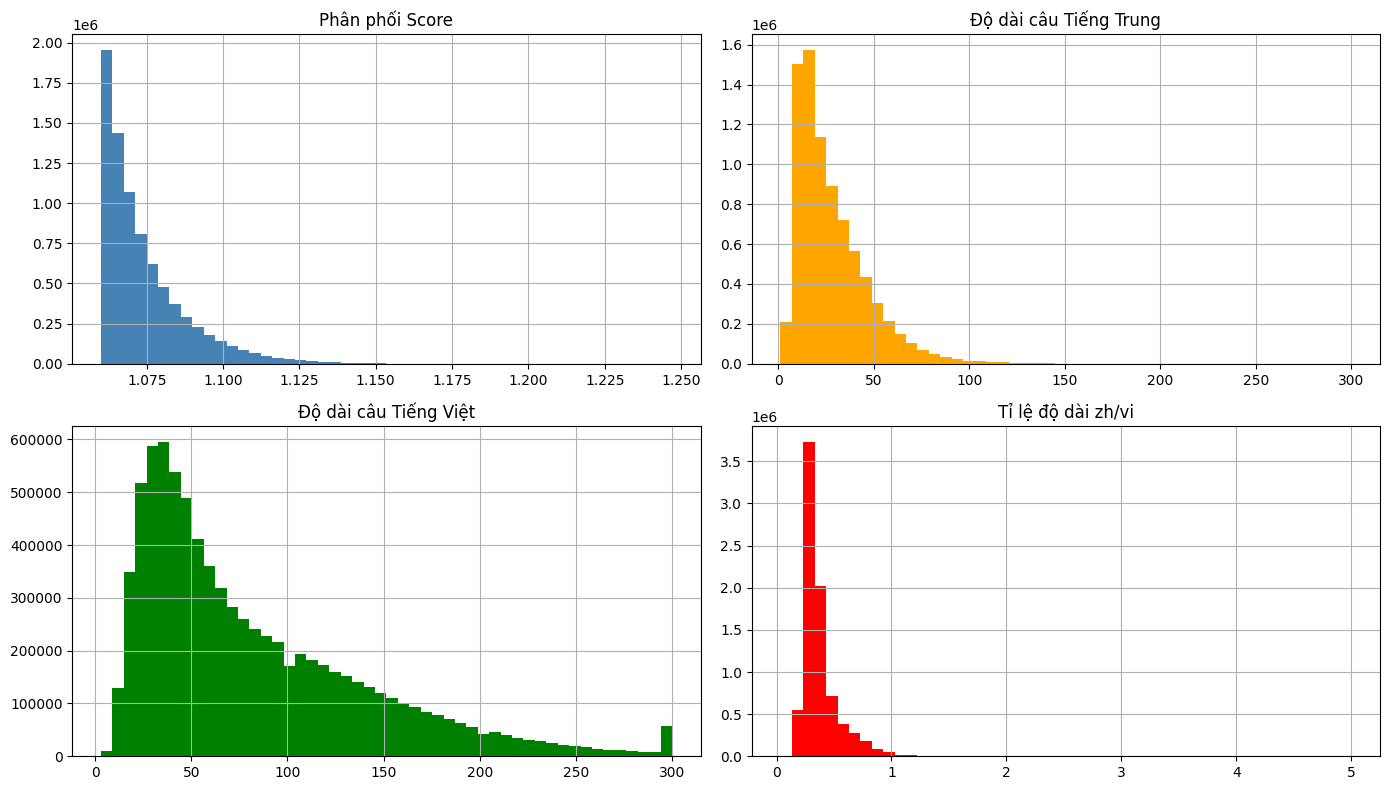

In [ ]:
df['zh_len'] = df['zh'].apply(len)
df['vi_len'] = df['vi'].apply(len)
df['zh_tokens'] = df['zh'].apply(lambda x: len(list(x)))
df['vi_tokens'] = df['vi'].apply(lambda x: len(x.split()))
df['len_ratio'] = df['zh_len'] / (df['vi_len'] + 1e-6)

print(df[['score','zh_len','vi_len','vi_tokens','len_ratio']].describe().round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
df['score'].hist(bins=50, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Phân phối Score')
df['zh_len'].clip(0,300).hist(bins=50, ax=axes[0,1], color='orange')
axes[0,1].set_title('Độ dài câu Tiếng Trung')
df['vi_len'].clip(0,300).hist(bins=50, ax=axes[1,0], color='green')
axes[1,0].set_title('Độ dài câu Tiếng Việt')
df['len_ratio'].clip(0,5).hist(bins=50, ax=axes[1,1], color='red')
axes[1,1].set_title('Tỉ lệ độ dài zh/vi')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_stats.png', dpi=150)
plt.show()

##### 1.2. Data Filtering & Normalize



###### 1.2.1. Null Filter

In [ ]:
def filter_nulls(df):
  """Loại NaN và đảm bảo kiểu string"""
  before = len(df)
  df = df.dropna(subset=['zh','vi']).copy()
  df['zh'] = df['zh'].astype(str).str.strip()
  df['vi'] = df['vi'].astype(str).str.strip()
  df = df[(df['zh'] != '') & (df['vi'] != '')].copy()
  print(f"[Null filter] {before:>10,} -> {len(df):>10,} (loại {before-len(df):>8,})")
  return df

###### 1.2.2. Score Filter (LASER embedding similarity)
*   CCMatrix score thường từ 1.0 đến 1.3+
*   Ngưỡng khuyến nghị: >= 1.05 (cân bằng chất lượng vs số lượng)

In [ ]:
def filter_score(df, threshold=1.05):
  """Loại cặp câu có độ tương đồng ngữ nghĩa thấp"""
  before = len(df)
  df = df[df['score'] >= threshold].copy()
  print(f"[Score filter] {before:>10,} -> {len(df):>10,} (loại {before-len(df):>8,})")
  return df

######   1.2.3. Length Filter (Lọc độ dài câu)

In [ ]:
df['zh_tokens'] = df['zh'].apply(lambda x: len(list(x)))  # mỗi ký tự Hán = 1 token

def filter_length(df, min_zh=4, max_zh=150, min_vi=3, max_vi=100):
  """Loại câu quá ngắn hoặc quá dài"""
  before = len(df)
  mask = (
      (df['zh_len'] >= min_zh) & (df['zh_len'] <= max_zh) &
      (df['vi_tokens'] >= min_vi) & (df['vi_tokens'] <= max_vi)
  )
  df = df[mask].copy()
  print(f"[Length filter] {before:>10,} -> {len(df):>10,} (loại {before-len(df):>8,})")
  return df

###### 1.2.4. Length Ratio Filter (Lọc tỉ lệ độ dài)
*   Cặp câu hợp lệ thường có tỉ lệ ký tự zh/vi ~ 0.4–1.5
*   Tiếng Trung dùng ký tự biểu ý nên nén hơn tiếng Việt. Tỉ lệ thực tế của CCMatrix zh-vi thường là 0.3–0.8 (1 ký tự Hán ~ 2–3 ký tự Latin có dấu)

In [ ]:
def filter_ratio(df, min_ratio=0.18, max_ratio=1.2):
  """Loại cặp câu lệch độ dài bất thường"""
  before = len(df)
  mask = (df['len_ratio'] >= min_ratio) & (df['len_ratio'] <= max_ratio)
  df = df[mask].copy()
  print(f"[Ratio filter] {before:>10,} -> {len(df):>10,} (loại {before-len(df):>8,})")
  return df

###### 1.2.5. Content Filter (Lọc nội dung không hợp lệ)
Loại các câu:
* Toàn số/ký tự đặc biệt -> không có giá trị ngôn ngữ
* Chứa URL -> không phải ngôn ngữ tự nhiên
* Ký tự lặp liên tiếp -> spam
* Hai vế giống hệt nhau -> không được dịch

In [ ]:
def filter_content(df):
  """Loại URL, spam ký tự lặp, câu không được dịch"""
  before = len(df)
  url = r'http[s]?://|www\.'
  repeat = re.compile(r'(.)\1{4,}')
  numeric = r'^[\d\s\W]+$'
  mask = (
      ~df['zh'].str.fullmatch(r'[\d\s\W]+') &
      ~df['vi'].str.fullmatch(r'[\d\s\W]+') &
      ~df['zh'].str.contains(url, regex=True) &
      ~df['vi'].str.contains(url, regex=True) &
      ~df['zh'].apply(lambda x: bool(repeat.search(x))) &
      ~df['vi'].apply(lambda x: bool(repeat.search(x))) &
      (df['zh'] != df['vi'])
  )
  df = df[mask].copy()
  print(f"[Content filter] {before:>10,} -> {len(df):>10,} (loại {before-len(df):>8,})")
  return df

###### 1.2.6. Noise Char Filter

In [ ]:
def filter_noise_chars(df):
  """Loại ký tự box-drawing và fullwidth dash lạ"""
  before = len(df)
  box_drawing = re.compile(r'[\u2500-\u257F]')
  odd_dashes = re.compile(r'[\uFF0D\u2015]')
  mask = (
      ~df['zh'].str.contains(box_drawing, regex=True) &
      ~df['vi'].str.contains(box_drawing, regex=True) &
      ~df['zh'].str.contains(odd_dashes, regex=True) &
      ~df['vi'].str.contains(odd_dashes, regex=True)
  )
  df = df[mask].copy()
  print(f"[Noise char filter] {before:>10,} -> {len(df):>10,} (loại {before-len(df):>8,})")
  return df

###### 1.2.7. CJK Ratio Filter

In [ ]:
def filter_cjk_ratio(df, min_ratio=0.3):
  """Loại câu zh chứa quá ít ký tự Hán"""
  before = len(df)
  cjk = re.compile(r'[\u4e00-\u9fff\u3400-\u4dbf]')
  def is_valid_zh(text):
    return len(cjk.findall(text)) / len(text) >= min_ratio if text else False
  df = df[df['zh'].apply(is_valid_zh)].copy()
  print(f"[CJK ratio filter] {before:>10,} -> {len(df):>10,} (loại {before-len(df):>8,})")
  return df

###### 1.2.8. VI Char Filter

In [ ]:
def filter_vi_chars(df, min_ratio=0.5):
  """Loại câu vi chứa quá ít ký tự Latin"""
  before = len(df)
  latin = re.compile(r'[a-zA-Z\u00C0-\u024F\u1E00-\u1EFF]')
  def is_valid_vi(text):
      return len(latin.findall(text)) / len(text) >= min_ratio if text else False
  df = df[df['vi'].apply(is_valid_vi)].copy()
  print(f"[VI char filter] {before:>10,} -> {len(df):>10,} (loại {before-len(df):>8,})")
  return df

###### 1.2.9. Deduplication Filter (Lọc câu trùng lặp)

In [ ]:
def deduplication(df):
  """Loại câu trùng lặp, giữ bản có score cao nhất"""
  before = len(df)
  df = df.drop_duplicates(subset=['zh','vi'])
  df = df.sort_values('score', ascending=False)
  df = df.drop_duplicates(subset=['zh'], keep='first')
  df = df.drop_duplicates(subset=['vi'], keep='first')
  print(f"[Dedup filter] {before:>10,} -> {len(df):>10,} (loại {before-len(df):>8,})")
  return df

###### 1.2.10. Normalize (Chuẩn hóa văn bản)
* Phồn thể -> Giản thể (OpenCC)
> CCMatrix có cả văn bản Giản thể (大陆) lẫn Phồn thể (台灣/香港). Nếu để lẫn lộn, tokenizer sẽ coi 學 và 学 là hai token khác nhau dù cùng nghĩa -> lãng phí vocabulary.
*  Unicode NFC Normalization (Chuẩn hóa Unicode NFC):
> Tiếng Việt có dấu có thể được encode theo 2 cách:
> * NFC: ộ = 1 code point (U+1ED9)
> * NFD: ộ = 3 code points (o + combining hook + combining dot)
> * Nếu không chuẩn hóa, "học" NFC và "học" NFD trông giống nhau nhưng máy tính coi là khác nhau -> dedup không hoạt động, tokenizer bị rối.
* Chuẩn hóa dấu câu
> Văn bản Trung dùng dấu câu fullwidth (，。！？) trong khi mô hình NMT thường được train với dấu câu ASCII (,.!?). Chuẩn hóa giúp giảm vocabulary size và tăng khả năng khớp với pretrained tokenizer.
* Xóa khoảng trắng thừa
* Viết thường

In [ ]:
!pip install opencc-python-reimplemented

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.8/481.8 kB 14.3 MB/s eta 0:00:00


In [ ]:
import opencc
import unicodedata

In [ ]:
converter = opencc.OpenCC('t2s')

ZH_PUNCTUATION_MAP = str.maketrans({
    ord('\uff0c'): ',',
    ord('\u3002'): '.',
    ord('\uff01'): '!',
    ord('\uff1f'): '?',
    ord('\uff1b'): ';',
    ord('\uff1a'): ':',
    ord('\u300c'): '"',
    ord('\u300d'): '"',
    ord('\u300e'): "'",
    ord('\u300f'): "'",
    ord('\uff08'): '(',
    ord('\uff09'): ')',
    ord('\u3000'): ' ',
})

VI_PUNCTUATION_MAP = str.maketrans({
    ord('\u201c'): '"',
    ord('\u201d'): '"',
    ord('\u2018'): "'",
    ord('\u2019'): "'",
    ord('\u2013'): '-',
    ord('\u2014'): '-',
})

In [ ]:
def normalize_zh(text):
  text = converter.convert(text)
  text = unicodedata.normalize('NFC', text)
  text = text.translate(ZH_PUNCTUATION_MAP)
  text = re.sub(r'\s+', ' ', text).strip()
  return text

def normalize_vi(text):
  text = unicodedata.normalize('NFC', text)
  text = text.translate(VI_PUNCTUATION_MAP)
  text = re.sub(r'\s+', ' ', text).strip()
  return text

###### 1.2.11. Filter Result

In [ ]:
df_clean = df.copy()
df_clean = filter_nulls(df_clean)
df_clean = filter_score(df_clean)
df_clean = filter_length(df_clean)
df_clean = filter_ratio(df_clean)
df_clean = filter_content(df_clean)
df_clean = filter_noise_chars(df_clean)
df_clean = filter_cjk_ratio(df_clean)
df_clean = filter_vi_chars(df_clean)

df_clean['zh'] = df_clean['zh'].apply(normalize_zh)
df_clean['vi'] = df_clean['vi'].apply(normalize_vi)

df_clean = deduplication(df_clean)

[Null filter]  8,045,074 ->  8,045,074 (loại        0)
[Score filter]  8,045,074 ->  8,045,074 (loại        0)
[Length filter]  8,045,074 ->  8,004,809 (loại   40,265)
[Ratio filter]  8,004,809 ->  7,960,964 (loại   43,845)
[Content filter]  7,960,964 ->  7,939,225 (loại   21,739)
[Noise char filter]  7,939,225 ->  7,915,879 (loại   23,346)
[CJK ratio filter]  7,915,879 ->  7,242,629 (loại  673,250)
[VI char filter]  7,242,629 ->  7,225,532 (loại   17,097)
[Dedup filter]  7,225,532 ->  5,363,045 (loại 1,862,487)


In [ ]:
print(f"Kết quả: {len(df):,} -> {len(df_clean):,} (giữ {len(df_clean)/len(df):.1%})")

Kết quả: 8,045,074 -> 5,363,045 (giữ 66.7%)


In [ ]:
print(df_clean[['zh','vi']].sample(5, random_state=42).to_string())

                                                                       zh                                                                                                                                                                                                                                                                                                                 vi
2327567  比如:你开车去上班,可以轻声(或在头脑中)感谢早上吃的食物,感谢雨水浇灌树木,感谢公车带你按时到达目的地,感谢雨衣让你没被淋湿.  Ví dụ: nếu bạn đang trên đường đi làm bằng xe buýt, bạn có thể bắt đầu thì thầm (hoặc tự nhủ trong đầu) lời cảm ơn thức ăn mà bạn đã dùng vào buối sáng hôm đó, cảm ơn cơn mưa đã tưới nước cho cây cối, cảm ơn chiếc xe buýt đã kịp thời đưa bạn đến nơi, cảm ơn chiếc áo mưa đã giúp bạn không bị ướt nước mưa.
7189287                                                  “好了,该走了,都累了一整天了.                                                                                                                                                                     

##### 1.3. Split the training set

In [ ]:
df_clean = df_clean.nlargest(500_000, 'score').reset_index(drop=True)

# Shuffle
df_clean = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)

DEV_SIZE  = 3000
TEST_SIZE = 3000

df_test  = df_clean.iloc[:TEST_SIZE]
df_dev   = df_clean.iloc[TEST_SIZE:TEST_SIZE + DEV_SIZE]
df_train = df_clean.iloc[TEST_SIZE + DEV_SIZE:]

print(f"Train: {len(df_train):,} | Dev: {len(df_dev):,} | Test: {len(df_test):,}")

for name, split in [('train', df_train), ('dev', df_dev), ('test', df_test)]:
    split[['zh','vi']].to_csv(f'{OUTPUT_DIR}/{name}.tsv', sep='\t', index=False, header=False)
    with open(f'{OUTPUT_DIR}/{name}.zh', 'w', encoding='utf-8') as f:
        f.writelines(s + '\n' for s in split['zh'])
    with open(f'{OUTPUT_DIR}/{name}.vi', 'w', encoding='utf-8') as f:
        f.writelines(s + '\n' for s in split['vi'])

print(f"Đã lưu vào {OUTPUT_DIR}")

Train: 494,000 | Dev: 3,000 | Test: 3,000
Đã lưu vào /content/drive/MyDrive/school/nlp/doan/processed


##### 1.4. Train SentencePiece

In [ ]:
!pip install --upgrade transformers[sentencepiece]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 90.7 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import sentencepiece as spm

In [ ]:
# Train tokenizer tiếng Trung
spm.SentencePieceTrainer.train(
    input=f'{OUTPUT_DIR}/train.zh',
    model_prefix=f'{OUTPUT_DIR}/spm_zh',
    vocab_size=8000,
    character_coverage=0.9999,
    model_type='bpe',
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
    input_sentence_size=500_000,
    shuffle_input_sentence=True,
)

# Train tokenizer tiếng Việt
spm.SentencePieceTrainer.train(
    input=f'{OUTPUT_DIR}/train.vi',
    model_prefix=f'{OUTPUT_DIR}/spm_vi',
    vocab_size=16000,
    character_coverage=1.0,
    model_type='bpe',
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
    input_sentence_size=500_000,
    shuffle_input_sentence=True,
)

In [ ]:
# --- Kiểm tra ---
sp_zh = spm.SentencePieceProcessor()
sp_vi = spm.SentencePieceProcessor()
sp_zh.load(f'{OUTPUT_DIR}/spm_zh.model')
sp_vi.load(f'{OUTPUT_DIR}/spm_vi.model')

test_cases_zh = [
    "我爱自然语言处理",
    "专家们警告朝鲜继续推进武器计划",
    "数千年来茴香一直被用作消化辅助剂",
]
test_cases_vi = [
    "Tôi yêu xử lý ngôn ngữ tự nhiên",
    "Chuyên gia cảnh báo về chương trình vũ khí hạt nhân",
    "Trong hàng ngàn năm hạt thì là đã được sử dụng như một chất hỗ trợ tiêu hóa",
]

print("=== TOKENIZER TIẾNG TRUNG ===")
for text in test_cases_zh:
    tokens = sp_zh.encode(text, out_type=str)
    print(f"({len(tokens):2d} tokens): {tokens}")

print("\n=== TOKENIZER TIẾNG VIỆT ===")
for text in test_cases_vi:
    tokens = sp_vi.encode(text, out_type=str)
    print(f"({len(tokens):2d} tokens): {tokens}")

=== TOKENIZER TIẾNG TRUNG ===
( 5 tokens): ['▁我', '爱', '自然', '语言', '处理']
(10 tokens): ['▁', '专家', '们', '警告', '朝鲜', '继续', '推', '进', '武器', '计划']
(14 tokens): ['▁', '数千', '年来', '茴', '香', '一直', '被', '用', '作', '消', '化', '辅', '助', '剂']

=== TOKENIZER TIẾNG VIỆT ===
( 8 tokens): ['▁Tôi', '▁yêu', '▁xử', '▁lý', '▁ngôn', '▁ngữ', '▁tự', '▁nhiên']
(11 tokens): ['▁Chuyên', '▁gia', '▁cảnh', '▁báo', '▁về', '▁chương', '▁trình', '▁vũ', '▁khí', '▁hạt', '▁nhân']
(18 tokens): ['▁Trong', '▁hàng', '▁ngàn', '▁năm', '▁hạt', '▁thì', '▁là', '▁đã', '▁được', '▁sử', '▁dụng', '▁như', '▁một', '▁chất', '▁hỗ', '▁trợ', '▁tiêu', '▁hóa']


#### II. TRAINING TRANSFORMER

In [ ]:
!pip install torch sacrebleu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.8 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math, os, time, json
import numpy as np

OUTPUT_DIR = '/content/drive/MyDrive/school/2025-2026_Hk2/nlp/doan/zh-vi_processed_500k'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

MAX_LEN = 128   # dùng thống nhất cho cả Dataset, PositionalEncoding, Inference
PAD_ID = 0
BOS_ID = 2
EOS_ID = 3

Device : cuda


##### 2.1. DataLoader

In [ ]:
!pip install --upgrade transformers[sentencepiece]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 67.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import sentencepiece as spm

In [ ]:
# Load tokenizer
sp_zh = spm.SentencePieceProcessor()
sp_vi = spm.SentencePieceProcessor()
sp_zh.load(f'{OUTPUT_DIR}/spm_zh.model')
sp_vi.load(f'{OUTPUT_DIR}/spm_vi.model')

SRC_VOCAB = sp_zh.get_piece_size()
TGT_VOCAB = sp_vi.get_piece_size()
print(f"SRC vocab: {SRC_VOCAB} | TGT vocab: {TGT_VOCAB}")

SRC vocab: 8000 | TGT vocab: 16000


In [ ]:
class TranslationDataset(Dataset):
  def __init__(self, tsv_path, sp_src, sp_tgt, max_len=MAX_LEN):
    self.pairs = []
    with open(tsv_path, 'r', encoding='utf-8') as f:
      for line in f:
        parts = line.strip().split('\t')
        if len(parts) != 2:
          continue
        zh, vi = parts[0].strip(), parts[1].strip()
        if not zh or not vi:
          continue
        src = sp_src.encode(zh)
        tgt = sp_tgt.encode(vi)
        if len(src) + 1 > max_len or len(tgt) + 1 > max_len:
          continue
        self.pairs.append((src, tgt))

  def __len__(self):
    return len(self.pairs)

  def __getitem__(self, idx):
    return self.pairs[idx]


def collate_fn(batch):
  """Padding các câu trong batch về cùng độ dài."""
  if not batch:
    return None, None, None

  src_batch, tgt_batch = zip(*batch)
  src_eos = [s + [EOS_ID] for s in src_batch]

  # Decoder input: BOS + tokens; Decoder target: tokens + EOS
  tgt_in = [[BOS_ID] + t for t in tgt_batch]
  tgt_out = [t + [EOS_ID]  for t in tgt_batch]

  # Tính max riêng cho từng phía để tránh lệch
  src_max = max(len(s) for s in src_eos)
  tgt_max = max(max(len(t) for t in tgt_in),
                max(len(t) for t in tgt_out))

  src_padded = [s + [PAD_ID] * (src_max - len(s)) for s in src_eos]
  tgt_in_padded = [t + [PAD_ID] * (tgt_max - len(t)) for t in tgt_in]
  tgt_out_padded = [t + [PAD_ID] * (tgt_max - len(t)) for t in tgt_out]

  return (
      torch.tensor(src_padded,     dtype=torch.long),
      torch.tensor(tgt_in_padded,  dtype=torch.long),
      torch.tensor(tgt_out_padded, dtype=torch.long),
  )


# Tạo dataset & loader
train_ds = TranslationDataset(f'{OUTPUT_DIR}/train.tsv', sp_zh, sp_vi)
dev_ds = TranslationDataset(f'{OUTPUT_DIR}/dev.tsv',   sp_zh, sp_vi)
test_ds = TranslationDataset(f'{OUTPUT_DIR}/test.tsv',  sp_zh, sp_vi)

print(f'Train: {len(train_ds):,} | Dev: {len(dev_ds):,} | Test: {len(test_ds):,}')

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,
                          collate_fn=collate_fn, num_workers=4, pin_memory=True)
dev_loader = DataLoader(dev_ds, batch_size=128, shuffle=False,
                          collate_fn=collate_fn, num_workers=4, pin_memory=True)

Train: 493,998 | Dev: 3,000 | Test: 3,000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


##### 2.2. Transformer architecture

In [ ]:
class PositionalEncoding(nn.Module):
  """Thêm thông tin vị trí vào embedding."""

  def __init__(self, d_model, max_len=MAX_LEN, dropout=0.1):
    super().__init__()
    self.dropout = nn.Dropout(dropout)

    pe = torch.zeros(max_len, d_model)
    pos = torch.arange(0, max_len).unsqueeze(1).float()
    div = torch.exp(
        torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
    )
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

  def forward(self, x):
    # x: (batch, seq_len, d_model)
    return self.dropout(x + self.pe[:, :x.size(1)])

In [ ]:
class Seq2SeqTransformer(nn.Module):
  def __init__(
      self,
      src_vocab_size,
      tgt_vocab_size,
      d_model=256,
      nhead=8,
      num_encoder_layers=4,
      num_decoder_layers=4,
      dim_feedforward=1024,
      dropout=0.1,
      max_len=MAX_LEN,
  ):
    super().__init__()

    self.src_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD_ID)
    self.tgt_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=PAD_ID)
    self.pos_enc = PositionalEncoding(d_model, max_len, dropout)

    self.transformer = nn.Transformer(
        d_model=d_model,
        nhead=nhead,
        num_encoder_layers=num_encoder_layers,
        num_decoder_layers=num_decoder_layers,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        batch_first=True,
    )

    self.fc_out = nn.Linear(d_model, tgt_vocab_size)
    self.scale  = math.sqrt(d_model)
    self._init_weights()

  def _init_weights(self):
    for p in self.parameters():
      if p.dim() > 1:
        nn.init.xavier_uniform_(p)

  def make_src_key_padding_mask(self, src):
    """True tại vị trí PAD -> bị bỏ qua trong attention."""
    return src == PAD_ID  # (batch, src_len)

  def make_tgt_mask(self, tgt):
    """Causal mask: token hiện tại không nhìn được token tương lai."""
    return nn.Transformer.generate_square_subsequent_mask(
        tgt.size(1), device=tgt.device
    )

  def forward(self, src, tgt):
    src_emb = self.pos_enc(self.src_emb(src) * self.scale)
    tgt_emb = self.pos_enc(self.tgt_emb(tgt) * self.scale)

    tgt_mask = self.make_tgt_mask(tgt)
    src_pad_mask = self.make_src_key_padding_mask(src)
    tgt_pad_mask = self.make_src_key_padding_mask(tgt)

    out = self.transformer(
        src_emb, tgt_emb,
        tgt_mask=tgt_mask,
        src_key_padding_mask=src_pad_mask,
        tgt_key_padding_mask=tgt_pad_mask,
        memory_key_padding_mask=src_pad_mask,
    )
    return self.fc_out(out)  # (batch, tgt_len, tgt_vocab)

##### 2.3. Training

In [ ]:
# Khởi tạo model
model = Seq2SeqTransformer(
    src_vocab_size=SRC_VOCAB,
    tgt_vocab_size=TGT_VOCAB,
    d_model=256,
    nhead=8,
    num_encoder_layers=4,
    num_decoder_layers=4,
    dim_feedforward=1024,   # 4 × d_model
    dropout=0.1,
).to(DEVICE)

model = torch.compile(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Số tham số: {n_params:,}')

Số tham số: 17,629,824


In [ ]:
# Loss & Optimizer
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=0.1)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1.0,           # lr thực = lr_lambda * 1.0, do LambdaLR kiểm soát
    betas=(0.9, 0.98),
    eps=1e-9,
)

D_MODEL = 256
WARMUP = 4000

def lr_lambda(step):
  step = max(step, 1)
  return (D_MODEL ** -0.5) * min(step ** -0.5, step * WARMUP ** -1.5)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [ ]:
from torch.amp import GradScaler, autocast
scaler = GradScaler(device='cuda')

In [ ]:
# Hàm train 1 epoch
def train_epoch(model, loader, optimizer, criterion, scheduler):
  model.train()
  total_loss, total_tokens = 0.0, 0

  for src, tgt_in, tgt_out in loader:
    if src is None:   # guard batch rỗng
      continue
    src = src.to(DEVICE)
    tgt_in = tgt_in.to(DEVICE)
    tgt_out = tgt_out.to(DEVICE)

    optimizer.zero_grad()
    with autocast(device_type='cuda'):   # tự động dùng float16
      logits = model(src, tgt_in)
      loss   = criterion(logits.reshape(-1, TGT_VOCAB), tgt_out.reshape(-1))

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()
    scheduler.step()

    non_pad = (tgt_out != PAD_ID).sum().item()
    total_loss += loss.item() * non_pad
    total_tokens += non_pad

  return total_loss / total_tokens

# Hàm đánh giá trên dev set
@torch.no_grad()
def evaluate(model, loader, criterion):
  model.eval()
  total_loss, total_tokens = 0.0, 0

  for src, tgt_in, tgt_out in loader:
    if src is None:
      continue
    src = src.to(DEVICE)
    tgt_in = tgt_in.to(DEVICE)
    tgt_out = tgt_out.to(DEVICE)

    logits = model(src, tgt_in)
    loss = criterion(
        logits.reshape(-1, TGT_VOCAB),
        tgt_out.reshape(-1),
    )

    non_pad = (tgt_out != PAD_ID).sum().item()
    total_loss += loss.item() * non_pad
    total_tokens += non_pad

  return total_loss / total_tokens

In [ ]:
EPOCHS = 30
PATIENCE = 10
CKPT_PATH = f'{OUTPUT_DIR}/transformer_best.pt'

START_EPOCH = 1
best_dev_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'dev_loss': [], 'train_ppl': [], 'dev_ppl': []}

if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    START_EPOCH = ckpt['epoch'] + 1
    best_dev_loss = ckpt['dev_loss']
    print(f">>> Resume từ epoch {ckpt['epoch']}, dev_loss={ckpt['dev_loss']:.4f}")
else:
    print(">>> Train từ đầu")

header = f"{'Epoch':>5} {'LR':>10} {'Train Loss':>12} {'Train PPL':>12} {'Dev Loss':>10} {'Dev PPL':>10} {'Time':>8}"
print(header)
print('-' * len(header))

for epoch in range(START_EPOCH, EPOCHS + 1):
  t0 = time.time()

  train_loss = train_epoch(model, train_loader, optimizer, criterion, scheduler)
  dev_loss = evaluate(model, dev_loader, criterion)

  train_ppl = math.exp(min(train_loss, 20))
  dev_ppl = math.exp(min(dev_loss,   20))
  elapsed = time.time() - t0
  cur_lr = optimizer.param_groups[0]['lr']

  history['train_loss'].append(train_loss)
  history['dev_loss'].append(dev_loss)
  history['train_ppl'].append(train_ppl)
  history['dev_ppl'].append(dev_ppl)

  print(f"{epoch:>5} {cur_lr:>10.2e} {train_loss:>12.4f} {train_ppl:>12.2f} "
        f"{dev_loss:>10.4f} {dev_ppl:>10.2f} {elapsed:>7.1f}s")

  if dev_loss < best_dev_loss:
    best_dev_loss = dev_loss
    patience_counter = 0
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'dev_loss': dev_loss,
    }, CKPT_PATH)
    print(f'>>> Checkpoint lưu (dev_loss={dev_loss:.4f})')
  else:
    patience_counter += 1
    if patience_counter >= PATIENCE:
      print(f'\n>>> Early stopping tại epoch {epoch}')
      break

# Lưu history
with open(f'{OUTPUT_DIR}/history.json', 'w') as f:
    json.dump(history, f, indent=2)

print(f'\nBest dev loss: {best_dev_loss:.4f} | PPL: {math.exp(best_dev_loss):.2f}')

>>> Train từ đầu
Epoch         LR   Train Loss    Train PPL   Dev Loss    Dev PPL     Time
-------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
W0420 12:11:13.765000 3091 torch/_inductor/utils.py:1679] [1/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both

    1   9.54e-04       5.1039       164.66     3.5263      34.00   461.2s
>>> Checkpoint lưu (dev_loss=3.5263)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


    2   7.11e-04       3.3416        28.26     3.0268      20.63   441.5s
>>> Checkpoint lưu (dev_loss=3.0268)
    3   5.81e-04       3.0340        20.78     2.8838      17.88   441.4s
>>> Checkpoint lưu (dev_loss=2.8838)
    4   5.03e-04       2.9069        18.30     2.8158      16.71   442.4s
>>> Checkpoint lưu (dev_loss=2.8158)
    5   4.50e-04       2.8301        16.95     2.7621      15.83   442.7s
>>> Checkpoint lưu (dev_loss=2.7621)
    6   4.11e-04       2.7777        16.08     2.7372      15.44   445.2s
>>> Checkpoint lưu (dev_loss=2.7372)
    7   3.80e-04       2.7389        15.47     2.7090      15.01   443.7s
>>> Checkpoint lưu (dev_loss=2.7090)
    8   3.56e-04       2.7080        15.00     2.6940      14.79   444.3s
>>> Checkpoint lưu (dev_loss=2.6940)
    9   3.35e-04       2.6827        14.62     2.6804      14.59   441.4s
>>> Checkpoint lưu (dev_loss=2.6804)
   10   3.18e-04       2.6627        14.33     2.6768      14.54   442.8s
>>> Checkpoint lưu (dev_loss=2.6768)
 

##### 2.4. Inference

In [ ]:
# Load checkpoint tốt nhất
CKPT_PATH = f'{OUTPUT_DIR}/transformer_best.pt'
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Loaded epoch {ckpt['epoch']}, dev_loss={ckpt['dev_loss']:.4f}")

Loaded epoch 26, dev_loss=2.6212


In [ ]:
@torch.no_grad()
def translate(
    model, src_text, sp_src, sp_tgt,
    max_len=MAX_LEN, method='greedy',
    temperature=1.0, top_k=50,
):
  """
  Dịch một câu tiếng Trung sang tiếng Việt.

  method:
      'greedy' — chọn token có xác suất cao nhất ở mỗi bước.
      'topk'   — lấy mẫu ngẫu nhiên trong top-k token (đa dạng hơn).
  """
  model.eval()

  # Encode source
  src_ids = sp_src.encode(src_text) + [EOS_ID]
  src = torch.tensor([src_ids], dtype=torch.long).to(DEVICE)

  # Chạy encoder 1 lần duy nhất
  src_emb = model.pos_enc(model.src_emb(src) * model.scale)
  src_pad_mask = model.make_src_key_padding_mask(src)
  memory = model.transformer.encoder(src_emb, src_key_padding_mask=src_pad_mask)

  # Giải mã tự hồi quy (autoregressive)
  tgt_ids = [BOS_ID]
  for _ in range(max_len):
    tgt = torch.tensor([tgt_ids], dtype=torch.long).to(DEVICE)
    tgt_emb = model.pos_enc(model.tgt_emb(tgt) * model.scale)
    tgt_mask = model.make_tgt_mask(tgt)

    out = model.transformer.decoder(
        tgt_emb, memory,
        tgt_mask=tgt_mask,
        memory_key_padding_mask=src_pad_mask,
    )
    logits = model.fc_out(out[:, -1, :])   # (1, tgt_vocab)

    if method == 'greedy':
      next_id = logits.argmax(-1).item()
    else:  # top-k sampling
      logits = logits / temperature
      top_vals, top_ids = logits.topk(top_k, dim=-1)
      probs = F.softmax(top_vals, dim=-1)
      next_id = top_ids[0, torch.multinomial(probs, 1).item()].item()

    if next_id == EOS_ID:
      break
    tgt_ids.append(next_id)

  # Bỏ BOS khi decode
  return sp_tgt.decode(tgt_ids[1:])

In [ ]:
test_sentences = [
    '我爱自然语言处理',
    '今天天气很好',
    '机器翻译是自然语言处理的重要任务',
    '专家们警告朝鲜继续推进武器计划',
]

print('=== GREEDY DECODING ===')
for zh in test_sentences:
  vi = translate(model, zh, sp_zh, sp_vi, method='greedy')
  print(f'ZH: {zh}')
  print(f'VI: {vi if vi.strip() else "[rỗng]"}')
  print('-' * 50)

print('\n=== TOP-K SAMPLING (temperature=0.8) ===')
for zh in test_sentences:
  vi = translate(model, zh, sp_zh, sp_vi, method='topk', temperature=0.8, top_k=50)
  print(f'ZH: {zh}')
  print(f'VI: {vi if vi.strip() else "[rỗng]"}')
  print('-' * 50)

=== GREEDY DECODING ===


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


ZH: 我爱自然语言处理
VI: Tôi yêu ngôn ngữ tự nhiên để xử lý
--------------------------------------------------
ZH: 今天天气很好
VI: Thời tiết hôm nay rất tốt
--------------------------------------------------
ZH: 机器翻译是自然语言处理的重要任务
VI: Dịch máy là một nhiệm vụ quan trọng để xử lý ngôn ngữ tự nhiên
--------------------------------------------------
ZH: 专家们警告朝鲜继续推进武器计划
VI: Các chuyên gia cảnh báo Triều Tiên tiếp tục thúc đẩy kế hoạch vũ khí
--------------------------------------------------

=== TOP-K SAMPLING (temperature=0.8) ===
ZH: 我爱自然语言处理
VI: Tôi yêu ngôn ngữ tự nhiên đối phó
--------------------------------------------------
ZH: 今天天气很好
VI: Ngày nay thời tiết là ổn
--------------------------------------------------
ZH: 机器翻译是自然语言处理的重要任务
VI: Dịch máy là một nhiệm vụ quan trọng của xử lý ngôn ngữ tự nhiên
--------------------------------------------------
ZH: 专家们警告朝鲜继续推进武器计划
VI: Các chuyên gia cảnh báo Triều Tiên tiếp tục tiến hành kế hoạch vũ khí.
--------------------------------------------------


In [ ]:
import sacrebleu
from tqdm import tqdm

@torch.no_grad()
def evaluate_bleu(model, test_tsv_path, sp_src, sp_tgt, max_len=MAX_LEN):
    model.eval()
    hypotheses = []   # câu model dịch ra
    references = []   # câu dịch chuẩn

    with open(test_tsv_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    for line in tqdm(lines, desc='Evaluating BLEU'):
        parts = line.strip().split('\t')
        if len(parts) != 2:
            continue
        zh, vi_ref = parts[0].strip(), parts[1].strip()
        if not zh or not vi_ref:
            continue

        vi_hyp = translate(model, zh, sp_src, sp_tgt,
                           max_len=max_len, method='greedy')

        hypotheses.append(vi_hyp)
        references.append(vi_ref)

    # SacreBLEU tính BLEU
    bleu = sacrebleu.corpus_bleu(hypotheses, [references])
    print(f'\n=== KẾT QUẢ BLEU TRÊN TẬP TEST ({len(hypotheses):,} câu) ===')
    print(f'BLEU score : {bleu.score:.2f}')
    print(f'Brevity Penalty: {bleu.bp:.4f}')
    print(f'Ratio (hyp/ref) : {bleu.sys_len / bleu.ref_len:.4f}')

    # In thêm vài ví dụ để kiểm tra chất lượng
    print('\n--- Ví dụ ngẫu nhiên ---')
    import random
    indices = random.sample(range(len(hypotheses)), min(5, len(hypotheses)))
    for i in indices:
        print(f'REF: {references[i]}')
        print(f'HYP: {hypotheses[i]}')
        print('-' * 50)

    return bleu.score


bleu_score = evaluate_bleu(
    model,
    f'{OUTPUT_DIR}/test.tsv',
    sp_zh, sp_vi,
)

Evaluating BLEU: 100%|██████████| 3000/3000 [06:02<00:00,  8.27it/s]



=== KẾT QUẢ BLEU TRÊN TẬP TEST (3,000 câu) ===
BLEU score : 39.71
Brevity Penalty: 0.9669
Ratio (hyp/ref) : 0.9674

--- Ví dụ ngẫu nhiên ---
REF: Anh ấy nói rằng một khi anh ấy đã xem những người hoài nghi về khí hậu với cùng một sự nuông chiều, bạn có thể mua một người chú lập dị, nhưng bây giờ đôi găng tay đã tắt.
HYP: Ông nói rằng một khi ông quan sát những người hoài nghi khí hậu giống nhau, bạn có thể nhận được một chú lạ, nhưng bây giờ găng tay đã đóng cửa.
--------------------------------------------------
REF: Tới hôm nay, tôi chỉ có thể nói tất cả đều là vì cuộc sống.
HYP: Đến ngày hôm nay, tôi chỉ có thể nói tất cả đều vì cuộc sống.
--------------------------------------------------
REF: Cho nên, khi chúng ta có đức hạnh và khai ngộ, thiên thần sẽ ở quanh chúng ta, bảo hộ chúng ta và phục vụ chúng ta.
HYP: Vì vậy, khi chúng ta có đức hạnh và giác ngộ, các thiên thần sẽ xoay quanh chúng ta, bảo vệ chúng ta và phục vụ chúng ta.
-------------------------------------------------

In [ ]:
custom_sentences = [
    "今天我去市场买了很多蔬菜和水果",        # Hôm nay tôi đi chợ mua nhiều rau và trái cây
    "这部电影非常好看，我推荐你去看",          # Bộ phim này rất hay, tôi khuyên bạn nên xem
    "学习外语需要很多时间和努力",              # Học ngoại ngữ cần nhiều thời gian và nỗ lực
    "他在大学里学习计算机科学",               # Anh ấy học khoa học máy tính ở đại học
    "越南的美食非常丰富多样",                 # Ẩm thực Việt Nam rất phong phú đa dạng
]

for zh in custom_sentences:
    vi = translate(model, zh, sp_zh, sp_vi, method='greedy')
    print(f"ZH: {zh}")
    print(f"VI: {vi}")
    print("-" * 50)

ZH: 今天我去市场买了很多蔬菜和水果
VI: Hôm nay tôi đi chợ mua rất nhiều rau và trái cây
--------------------------------------------------
ZH: 这部电影非常好看，我推荐你去看
VI: Bộ phim này rất đẹp và tôi khuyên bạn nên xem
--------------------------------------------------
ZH: 学习外语需要很多时间和努力
VI: Học ngoại ngữ cần nhiều thời gian và nỗ lực
--------------------------------------------------
ZH: 他在大学里学习计算机科学
VI: Ông học Khoa học Máy tính tại Đại học
--------------------------------------------------
ZH: 越南的美食非常丰富多样
VI: Thực phẩm Mỹ ở Việt Nam rất giàu có
--------------------------------------------------


#####